# Cross-validation for *aggregated* hierarchical multinomial data

*Companion notebook for a Learning Bayesian Statistics listener question.*

**The setting.** I fit multinomial choice models — a unit (a customer, a survey respondent, an investor) repeatedly picks among $K$ categories, and I want the group-level preferences while sharing information across groups hierarchically.

The raw data is individual choices, but the number of rows gets large fast, so I aggregate it into per-group count vectors to make the hierarchical fit tractable: *customer 17 chose product categories $(3, 1, 0, 5)$ across 9 purchases.*

Note: this problem first arose with proprietary investor / deal-type choice data. The customer-purchase example here is synthetic but structurally identical.

Handed this type of data, the natural first model is **independent** random effects per category (it's the default in Bambi/brms-style fits). Modeling the **correlations between products**, i.e. do people who over-pick category 1 also over-pick category 2? is perhaps a non-obvious refinement. The workflow question is: are those correlations worth it? This is your typical model-comparison problem, but I don't find it quite straightforward to perform.

## 1. A scenario with known ground truth

Customers choose among $K=4$ product categories (category 0 is the reference/pivot). Each customer has a latent preference vector — **correlated** random effects in log-odds space. We simulate the individual choices (ground truth), then aggregate to the count vectors we fit on.  

The correlation and scale values below are arbitrary and just for demonstration purposes.

**A note on the pivot.** Category 0 is an arbitrary choice for pivot. I believe the logistic-normal is *reference-invariant* and the pivot doesn't matter as long as we have the full covariance. For the independent model below, however, this doesn't hold if I understand things correctly. Perhaps a better approach would be to use the symmetric `ZeroSumNormal`.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import multivariate_normal
from scipy.special import softmax
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

RNG = np.random.default_rng(33)

K = 4                      # product categories: 0 (pivot), 1, 2, 3
G = 60                     # customers (groups)
cats = [f"cat_{k}" for k in range(K)]

# population structure -- ARBITRARY illustrative values, not calibrated to real data.
# Only point that matters: the off-diagonals are nonzero (mixed +/-/~0).
mean_free = np.array([0.5, -0.3, 0.2])         # mean log-odds vs pivot, cats 1..3
sds = np.array([0.6, 0.9, 0.7])
corr = np.array([[1.0,  0.6, -0.3],
                 [0.6,  1.0,  0.1],
                 [-0.3, 0.1,  1.0]])            # nonzero off-diagonals (arbitrary)
cov = np.diag(sds) @ corr @ np.diag(sds)

free_eff = multivariate_normal.rvs(mean=mean_free, cov=cov, size=G, random_state=42)
logits_true = np.hstack([np.zeros((G, 1)), free_eff])
probs_true = softmax(logits_true, axis=1)

n_purchases = RNG.poisson(12, size=G) + 3      # ~3..30 purchases per customer
rows = []
for i in range(G):
    for c in RNG.choice(K, size=n_purchases[i], p=probs_true[i]):
        rows.append({"group_id": i, "cat_id": int(c)})
choices_df = pd.DataFrame(rows)
print(f"{len(choices_df)} individual choices across {G} customers "
      f"({n_purchases.min()}-{n_purchases.max()} per customer)")
choices_df.head()

917 individual choices across 60 customers (9-22 per customer)


,group_id,cat_id
0,0,1
1,0,1
2,0,1
3,0,3
4,0,1


### Aggregate to the per-group count vectors we fit on

In the real case fitting directly on the observations above was not possible on our computer hardware, at least not in a reasonable amount of time. So here we aggregate to simulate this experience.

In [2]:
def aggregate(df, G=G, K=K):
    M = np.zeros((G, K), dtype=int)
    np.add.at(M, (df["group_id"].values, df["cat_id"].values), 1)
    out = pd.DataFrame(M, columns=cats)
    out.insert(0, "group_id", np.arange(G))
    out["total"] = M.sum(axis=1)
    return out

agg_df = aggregate(choices_df)
agg_df.head()

,group_id,cat_0,cat_1,cat_2,cat_3,total
0,0,3,6,2,3,14
1,1,4,4,2,11,21
2,2,6,2,3,5,16
3,3,5,1,3,9,18
4,4,1,1,4,6,12


## 2. Two models: independent and correlated

Both are hierarchical logistic-normal multinomials with non-centered per-customer random effects. They differ in **one line**:

- **`independent`** — a diagonal covariance: each category's random effect varies on its own. (brms: `counts | trials(total) ~ (1 | group)`)
- **`correlated`** — an `LKJCholeskyCov` prior, so the random effects covary across products. (brms: `counts | trials(total) ~ (1 | i | group)`)

In [3]:
def fit_aggregated(agg, correlated, draws=600, tune=600, chains=4, seed=0,
                   log_likelihood=False):
    Gn = agg.shape[0]
    counts = agg[cats].values
    # one aggregated row per customer, in group_id order -> dims label everything
    coords = {"customer": np.arange(Gn), "cat": cats, "cat_free": cats[1:]}
    with pm.Model(coords=coords) as model:
        z = pm.Normal("z", 0, 1, dims=("customer", "cat_free"))
        if correlated:
            sd_dist = pm.HalfStudentT.dist(nu=3, sigma=2.5)
            chol, _, _ = pm.LKJCholeskyCov("chol", n=K - 1, eta=2, sd_dist=sd_dist)
            ge = pm.Deterministic("ge", pt.dot(z, chol.T),
                                  dims=("customer", "cat_free"))   # correlated effects
        else:
            sigma = pm.HalfStudentT("sigma", nu=3, sigma=2.5, dims="cat_free")
            ge = pm.Deterministic("ge", z * sigma,
                                  dims=("customer", "cat_free"))   # independent effects
        mu = pm.Normal("mu", 0, 1.5, dims="cat_free")
        logits = pt.concatenate([pt.zeros((Gn, 1)), ge + mu], axis=1)
        p = pm.math.softmax(logits, axis=1)
        pm.Multinomial("obs", p=p, n=counts.sum(1), observed=counts,
                       dims=("customer", "cat"))
        idata = pm.sample(draws=draws, tune=tune, chains=chains, cores=chains,
                          random_seed=seed, progressbar=False)
        if log_likelihood:
            pm.compute_log_likelihood(idata, progressbar=False)
    return model, idata

model_ind, idata_ind = fit_aggregated(agg_df, correlated=False, seed=1, log_likelihood=True)
model_cor, idata_cor = fit_aggregated(agg_df, correlated=True,  seed=2, log_likelihood=True)
print("both models fitted")

NUTS[nutpie]: [z, sigma, mu]
NUTS[nutpie]: [z, chol, mu]


both models fitted


### Do they sample cleanly? (and a note on priors)

The priors are deliberately weakly-informative and standard: `Normal(0, 1.5)` on the population means, `HalfStudentT(3, 2.5)` scales, and `LKJ(eta=2)` on the correlation. For brevity I **intentionally skip an explicit prior predictive check** here — in a full workflow you'd run `pm.sample_prior_predictive` and confirm the implied category probabilities are sensible. Let's still check convergence before reading anything off the fit:

In [4]:
# Convergence check across ALL parameters (including the random effects)
for name, idata in [("independent", idata_ind), ("correlated", idata_cor)]:
    ndiv = int(idata.sample_stats["diverging"].sum())
    rh = az.rhat(idata)
    es = az.ess(idata)
    max_rhat = float(max(rh[v].max() for v in rh.data_vars))
    min_ess = float(min(es[v].min() for v in es.data_vars))
    print(f"{name:11s}: divergences={ndiv}  max r_hat={max_rhat:.3f}  min ess_bulk={min_ess:.0f}")

independent: divergences=0  max r_hat=1.011  min ess_bulk=458


/Users/rjljr/devel/multinom/.venv/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


correlated : divergences=0  max r_hat=1.007  min ess_bulk=360


Clean (0 divergences, r̂≈1, healthy ESS), so we can interpret. Both models agree on the *marginal* category rates; only the correlated model can see the cross-product structure:

In [5]:
corr_post = idata_cor.posterior["chol_corr"].mean(dim=["chain", "draw"]).values
print("True correlation among free log-odds:\n", np.round(corr, 2))
print("\nCorrelated model recovers:\n", np.round(corr_post, 2))
print("\nIndependent model assumes this is exactly the identity (no off-diagonal).")

True correlation among free log-odds:
 [[ 1.   0.6 -0.3]
 [ 0.6  1.   0.1]
 [-0.3  0.1  1. ]]

Correlated model recovers:
 [[ 1.    0.62 -0.24]
 [ 0.62  1.   -0.09]
 [-0.24 -0.09  1.  ]]

Independent model assumes this is exactly the identity (no off-diagonal).


### Posterior predictive check: the marginals agree, the correlations don't

One simple check we can do is to look at the posterior predictive. As expected, both models have no trouble with the marginal category totals (left panel) since the model has enough parameters to fit this exactly.

So let's look here at the **across-customer correlation** between two categories' proportions: `cat_1` and `cat_2` (the pair with the strongest positive correlation in the true log-odds).

The right panel shows this statistic's posterior-predictive distribution under each model, with the observed value marked.

Sampling: [obs]
Sampling: [obs]


observed T=0.002 | independent mean=-0.250 | correlated mean=-0.093


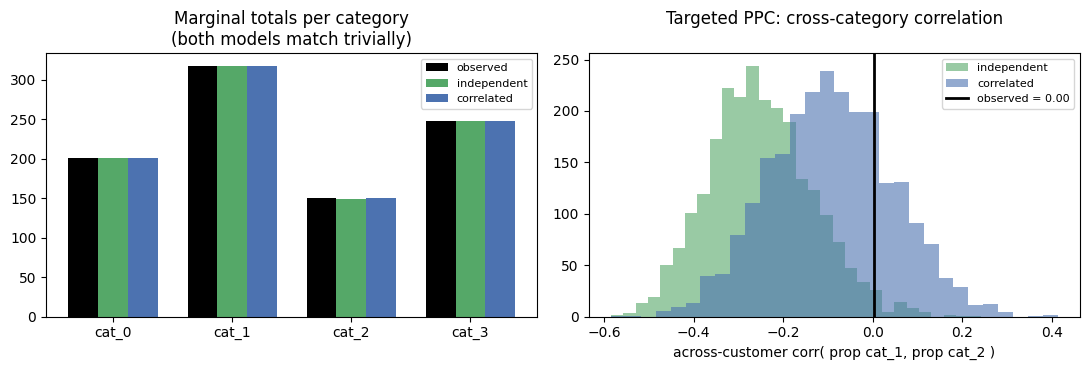

In [6]:
# In-sample posterior predictive via PyMC, reshaped to (samples, customers, cat)
def ppc_reps(model, idata, seed):
    with model:
        pm.sample_posterior_predictive(idata, extend_inferencedata=True,
                                       random_seed=seed, progressbar=False)
    da = idata.posterior_predictive["obs"]            # (chain, draw, customer, cat)
    return da.stack(s=("chain", "draw")).transpose("s", "customer", "cat").values

reps_ind = ppc_reps(model_ind, idata_ind, seed=11)
reps_cor = ppc_reps(model_cor, idata_cor, seed=12)

counts = agg_df[cats].values
tot = agg_df["total"].values
a, b = 1, 2                                              # discriminating category pair
def corr_T(reps):
    return np.array([np.corrcoef((r := reps[j] / tot[:, None])[:, a], r[:, b])[0, 1]
                     for j in range(len(reps))])
T_ind, T_cor = corr_T(reps_ind), corr_T(reps_cor)
T_obs = np.corrcoef((counts / tot[:, None])[:, a], (counts / tot[:, None])[:, b])[0, 1]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
x, w = np.arange(K), 0.25
ax[0].bar(x - w, counts.sum(0), w, label="observed", color="k")
ax[0].bar(x,     reps_ind.sum(1).mean(0), w, label="independent", color="#55A868")
ax[0].bar(x + w, reps_cor.sum(1).mean(0), w, label="correlated", color="#4C72B0")
ax[0].set_xticks(x); ax[0].set_xticklabels(cats)
ax[0].set_title("Marginal totals per category\n(both models match trivially)")
ax[0].legend(fontsize=8)
ax[1].hist(T_ind, bins=30, alpha=0.6, label="independent", color="#55A868")
ax[1].hist(T_cor, bins=30, alpha=0.6, label="correlated", color="#4C72B0")
ax[1].axvline(T_obs, color="k", lw=2, label=f"observed = {T_obs:.2f}")
ax[1].set_xlabel(f"across-customer corr( prop {cats[a]}, prop {cats[b]} )")
ax[1].set_title("Targeted PPC: cross-category correlation\n")
ax[1].legend(fontsize=8)
fig.tight_layout()
print(f"observed T={T_obs:.3f} | independent mean={T_ind.mean():.3f} | "
      f"correlated mean={T_cor.mean():.3f}")

## 3. ELPD — *which model is 'better'?*

Cross-validated elpd exists to **compare models** on predictive accuracy. This is how we decide whether the correlations are really useful. I think we want to compare predictive accuracy at the observation level, not at the group level. If we use `az.loo` on the aggregated data we are comparing at the group level, i.e. compare predictions on a new customer's whole count vector. There are cases where this is what you want, so let's try it anyway.

In [7]:
loo_ind, loo_cor = az.loo(idata_ind), az.loo(idata_cor)
comparison = az.compare({"independent": idata_ind, "correlated": idata_cor})
print(comparison[["rank", "elpd", "p", "elpd_diff", "dse", "warning"]])
print(f"\nLOO is over {loo_cor.n_data_points} units = the {G} CUSTOMERS (group-level target).")

             rank   elpd     p  elpd_diff  dse  warning
correlated      0 -360.0  67.4        0.0  0.0     True
independent     1 -370.0  71.2       -7.0  3.4     True

LOO is over 60 units = the 60 CUSTOMERS (group-level target).


/Users/rjljr/devel/multinom/.venv/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/rjljr/devel/multinom/.venv/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/rjljr/devel/m

In [8]:
def pareto_k_summary(loo, name):
    k = np.asarray(loo.pareto_k).ravel()
    print(f"{name:12s}: max k={k.max():.2f}  | bad (>0.7): {(k>0.7).sum()}/{len(k)}")
pareto_k_summary(loo_ind, "independent")
pareto_k_summary(loo_cor, "correlated")

independent : max k=1.23  | bad (>0.7): 34/60
correlated  : max k=1.28  | bad (>0.7): 30/60


Well that doesn't work well — we get high Pareto-k diagnostics. This is probably not a surprise: removing a group is a huge perturbation.

The answer is to reach instead for K-fold validation. There seem to be (at least) three different things we could do here:

1. K-fold on the rows of our aggregated table. This is the most straightforward, and if you care about predicting for new customers it would be the one to use. On the un-aggregated data this would (I believe) be equivalent in brms k-fold to `fold = grouped`.
2. K-fold on the individual 'disaggregated' data. Here my approach would be to disaggregate the data, form the folds, and re-aggregate the folds, fitting on each one. Perhaps this is fine for model comparison (predict a new observation, which may or may not be from an existing customer), but it doesn't seem to map to a real prediction question I would care about. This would correspond to using k-fold on the original observation data (unaggregated) and ignoring groups.
3. K-fold on the individual 'disaggregated' data, but now being careful, to the extent possible, to distribute each group's observations across the folds separately (`fold = stratified`?). This seems closer to what I want: how well can the model predict, for an existing customer, the next purchase? It is a bit messy though.

There is also [Neufeld, Dharamshi, Gao & Witten (2023), *Data thinning for convolution-closed distributions*](https://arxiv.org/abs/2301.07276), which proposes splitting a count vector into independent "train" and "test" parts **directly**, without ever materializing individual records — but to be honest I haven't had time to look at this yet.

In short: **after I aggregate for computation, what is the principled, scalable way to cross-validate and *compare models*?** Again, assume that doing the fit on individual observation data is intractable. (Although perhaps some kind of batch method could be used?)